In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv
/kaggle/input/datasets/henryshan/student-performance-prediction/por2.csv
/kaggle/input/datasets/henryshan/student-performance-prediction/mat2.csv


In [2]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [3]:
# 2. Load Dataset
# LOAD DATA (KAGGLE PATH)
df = pd.read_csv('/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv', encoding='ISO-8859-1')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
# 3. Data Preprocessing
# Select features and target
target = "G3"
X = df.drop(columns=[target])
y = df[target]

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

# Preprocess categorical variables with OneHotEncoder
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

Categorical columns: Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')
Numerical columns: Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object')


In [5]:
# 4. Train‑Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# 5. Model Training

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# LINEAR REGRESSION
lr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# DECISION TREE
dt_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeRegressor(random_state=42))
])

# RANDOM FOREST
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])  # <-- fixed the missing parenthesis

# Train models
print("Training Linear Regression...")
lr_model.fit(X_train, y_train)

print("Training Decision Tree...")
dt_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

Training Linear Regression...
Training Decision Tree...
Training Random Forest...


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [7]:
# 6. Model Evaluation
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return mae, rmse, r2

results = {}

results["Linear Regression"] = evaluate(lr_model, X_test, y_test)
results["Decision Tree"] = evaluate(dt_model, X_test, y_test)
results["Random Forest"] = evaluate(rf_model, X_test, y_test)

# Display results
print("\nMODEL EVALUATION RESULTS")
print("Model\t\tMAE\tRMSE\tR2")
for model_name, metrics in results.items():
    mae, rmse, r2 = metrics
    print(f"{model_name}:\t{mae:.2f}\t{rmse:.2f}\t{r2:.2f}")



MODEL EVALUATION RESULTS
Model		MAE	RMSE	R2
Linear Regression:	1.65	2.38	0.72
Decision Tree:	1.28	2.34	0.73
Random Forest:	1.18	2.00	0.80


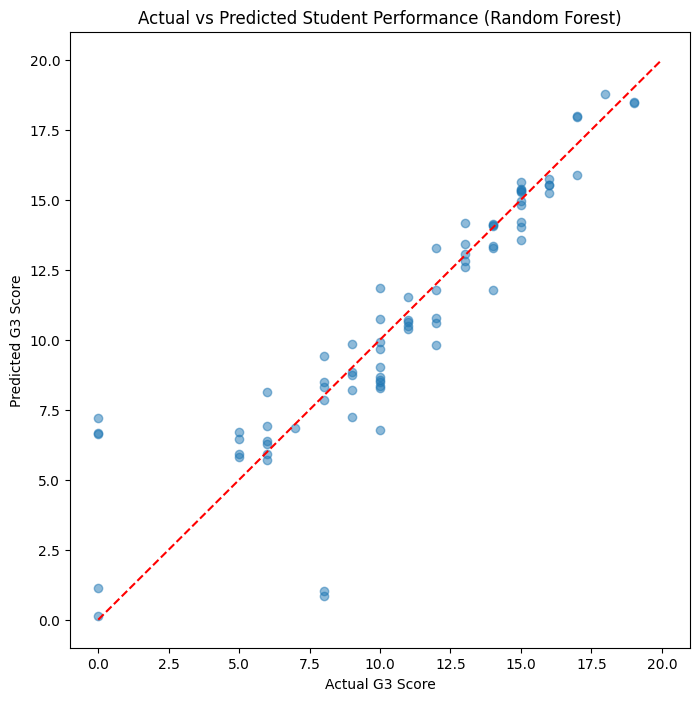

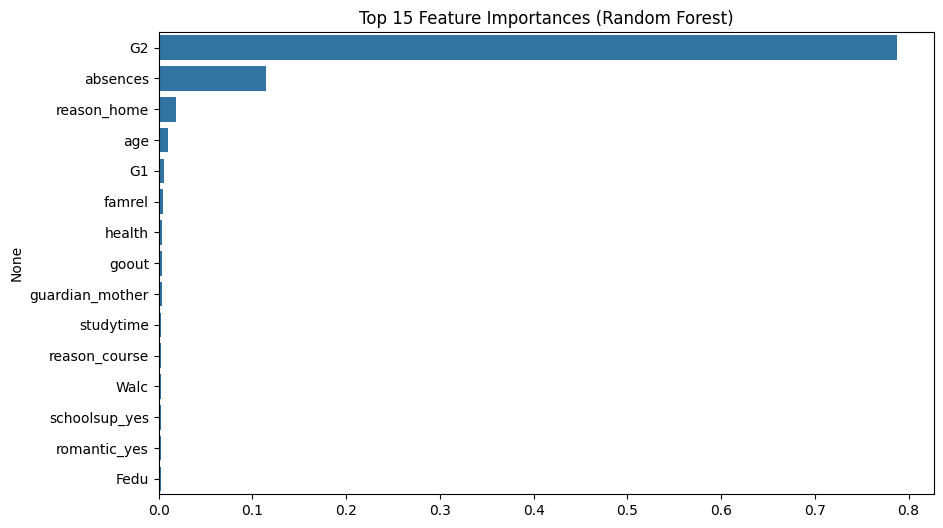

In [8]:
# 7. Visualizations


# 7.1 Actual vs Predicted (Random Forest)
best_model = rf_model
preds = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, preds, alpha=0.5)
plt.xlabel("Actual G3 Score")
plt.ylabel("Predicted G3 Score")
plt.title("Actual vs Predicted Student Performance (Random Forest)")
plt.plot([0, 20], [0, 20], "--r")
plt.show()

# 7.2 Feature Importance (Random Forest)
# Only possible after preprocessing - we get names after one‑hot encoding
oh_encoder = best_model.named_steps["preprocess"].named_transformers_["cat"]
encoded_cat_names = oh_encoder.get_feature_names_out(cat_cols)
all_features = np.hstack([encoded_cat_names, num_cols])

importance = best_model.named_steps["model"].feature_importances_
feature_importance = pd.Series(importance, index=all_features).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

In [9]:
print(df.shape)

(395, 33)


In [10]:
preds

array([ 8.275, 11.785,  6.695,  9.68 ,  8.84 , 12.795, 18.77 ,  6.915,
        7.205, 13.275, 15.62 ,  6.86 , 14.035, 11.855, 14.07 ,  8.3  ,
        1.04 , 10.62 , 15.385,  6.665, 14.125, 15.74 , 15.25 ,  6.29 ,
        6.62 , 18.49 , 10.5  ,  9.82 , 17.985, 10.75 ,  8.49 ,  8.485,
       15.285, 13.07 ,  0.83 ,  6.47 ,  0.13 , 14.96 , 11.765,  7.86 ,
        5.92 , 10.395, 14.085,  8.215, 14.82 ,  6.78 , 11.535, 14.175,
       12.615, 15.535, 13.43 , 15.33 , 10.58 ,  8.565,  5.71 , 13.27 ,
       10.705,  1.13 , 15.515, 15.895, 13.335,  8.68 ,  8.345,  6.39 ,
        7.25 , 17.965,  9.425,  9.025,  9.86 , 15.325,  8.145,  9.915,
       13.565, 18.445, 10.775,  5.935,  8.725, 14.21 ,  5.815])

In [11]:
y_test

78     10
371    12
248     5
55     10
390     9
       ..
364    12
82      6
114     9
3      15
18      5
Name: G3, Length: 79, dtype: int64

In [12]:
mae

1.1779113924050635

In [13]:
rmse

np.float64(2.00135752978455)

In [14]:
r2

0.8046611690447911

In [15]:
results

{'Linear Regression': (1.6466656197147522,
  np.float64(2.3783697847961376),
  0.7241341236974019),
 'Decision Tree': (1.2784810126582278,
  np.float64(2.3411562652304627),
  0.7326993404807303),
 'Random Forest': (1.1779113924050635,
  np.float64(2.00135752978455),
  0.8046611690447911)}